In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, interpolate

rng=np.random.default_rng()

3.1588


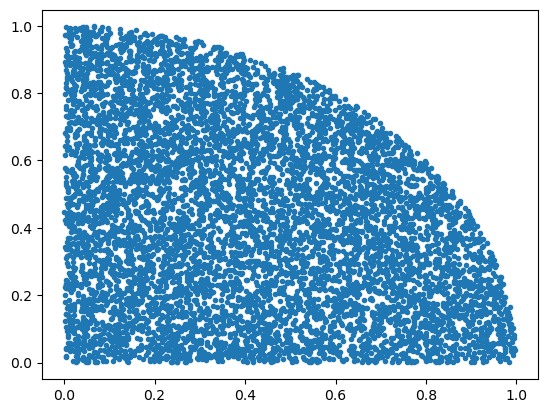

In [3]:
N=10000
x=np.linspace(-1,1,N)
y=np.sqrt(1-x**2)

x_rand=rng.random(N)
y_rand=rng.random(N)

is_inside = y_rand <= np.sqrt(1-x_rand**2)

print(4*np.sum(is_inside)/N)
fig,ax=plt.subplots()
ax.plot(x_rand[is_inside],y_rand[is_inside],".")


In [23]:
N=10000000
dim=10

coords=rng.random((dim,N))

r=0
for i in coords:
    r=r+i**2

print((2**dim)*np.sum(np.sqrt(r)<1)/N)

2.5284608


In [12]:
# Draw from N(0, 1/sqrt(2)) ~ (1/sqrt(pi))*exp(-x^(-2))
x = rng.normal(0, 1/np.sqrt(2), size=100000)
# Take the average. f has to cancel the (1/sqrt(pi)) from p(x)
expect = np.mean(np.sqrt(np.pi)/(np.sqrt(1 + x**2)))
print(expect)

1.524366390177537


In [30]:
my_int = lambda x: (x**2 + x)*np.exp(-x)/np.sqrt(x)
quad_out, err = integrate.quad(my_int, 0, np.inf)
print(quad_out)

2.215567313631897


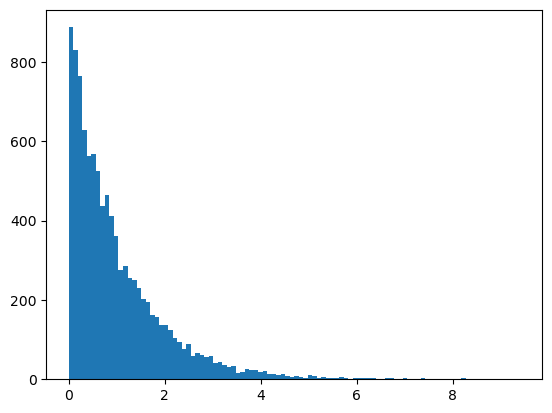

In [34]:
x=np.linspace(1e-6,10,100)
p_x=np.exp(-x)

cdf_px=np.cumsum(p_x)/np.sum(p_x) #normalized as well
inv_cdf=interpolate.interp1d(cdf_px,x)

draw_nums=rng.uniform(min(cdf_px), max(cdf_px), 10000)

plt.hist(inv_cdf(draw_nums), bins=100)
plt.show()